In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
df = pd.read_csv('/content/global-data-on-sustainable-energy (1).csv')


## Initial Data Exploration

Let's begin by examining the first few rows of the dataset to get a sense of its structure, column names, and the type of data it contains.

In [2]:
display(df.head())


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


Next, we'll check the general information about the DataFrame, including the data types of each column and the number of non-null values. This helps us identify potential issues like incorrect data types or missing values.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TW

Finally, we'll generate descriptive statistics for the numerical columns. This will give us a summary of the central tendency, dispersion, and shape of the dataset's distribution, helping us understand the range and variability of the numerical features.

In [4]:
display(df.describe())


,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3649.000000,3639.000000,3480.000000,2718.000000,1.560000e+03,3455.000000,3628.000000,3523.000000,3628.000000,3607.000000,3649.000000,3442.000000,3.221000e+03,1512.000000,3332.000000,3367.000000,3.648000e+03,3648.000000,3648.000000
mean,2010.038367,78.933702,63.255287,113.137498,9.422400e+07,32.638165,70.365003,13.450190,23.968010,36.801182,25743.981745,5.307345,1.598665e+05,11.986707,3.441610,13283.774348,6.332135e+05,18.246388,14.822695
std,6.054228,30.275541,39.043658,244.167256,2.981544e+08,29.894901,348.051866,73.006623,104.431085,34.314884,34773.221366,3.532020,7.736611e+05,14.994644,5.686720,19709.866716,1.585519e+06,24.159232,66.348148
min,2000.000000,1.252269,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110000,1.000000e+01,0.000000,-62.075920,111.927225,2.100000e+01,-40.900557,-175.198242
25%,2005.000000,59.800890,23.175000,3.540000,2.600000e+05,6.515000,0.290000,0.000000,0.040000,2.877847,3116.737300,3.170000,2.020000e+03,2.137095,1.383302,1337.813437,2.571300e+04,3.202778,-11.779889
50%,2010.000000,98.361570,83.150000,32.910000,5.665000e+06,23.300000,2.970000,0.000000,1.470000,27.865068,13120.570000,4.300000,1.050000e+04,6.290766,3.559855,4578.633208,1.176000e+05,17.189877,19.145136
75%,2015.000000,100.000000,100.000000,112.210000,5.534750e+07,55.245000,26.837500,0.000000,9.600000,64.403792,33892.780000,6.027500,6.058000e+04,16.841638,5.830099,15768.615365,5.131200e+05,38.969719,46.199616
max,2020.000000,100.000000,100.000000,3060.190000,5.202310e+09,96.040000,5184.130000,809.410000,2184.940000,100.000010,262585.700000,32.570000,1.070722e+07,86.836586,123.139555,123514.196700,9.984670e+06,64.963051,178.065032


## Data Cleaning: Column Renaming and Type Conversion

I've observed that the column `Density\n(P/Km2)` has a newline character in its name and is currently of `object` data type. This is problematic for analysis and might indicate hidden non-numeric values. My first step will be to rename this column to `Density (P/Km2)` for better readability and then investigate its contents to convert it to a numeric type.

In [11]:
# Rename the column 'Density\n(P/Km2)' to 'Density (P/Km2)'
# Explicitly build a new list of column names and assign it to df.columns for robustness
new_column_names = []
target_old_name_found = False
new_col_name = 'Density (P/Km2)' # Desired new column name

for col in df.columns:
    # Check if the column contains 'Density' and '(P/Km2)' to identify it, despite potential newline characters
    if 'Density' in col and '(P/Km2)' in col:
        new_column_names.append(new_col_name)
        target_old_name_found = True
    else:
        new_column_names.append(col)

if target_old_name_found:
    df.columns = new_column_names
    print(f"Column successfully renamed to '{new_col_name}'.")
else:
    print(f"Warning: Original 'Density (P/Km2)' column not found. Current columns: {df.columns.tolist()}")

# Inspect unique values to identify non-numeric entries
display(df[new_col_name].value_counts(dropna=False))

# Display data types again to confirm the rename (type conversion will happen in next steps)
df.info()

Column successfully renamed to 'Density (P/Km2)'.


,count
Density (P/Km2),
25,147
18,113
4,105
26,63
17,63
...,...
118,21
79,21
36,21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 19 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3649 non-null   float64
 3   Access to clean fuels for cooking                                 3649 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              3649 non-null   float64
 5   Renewable energy share in the total final energy consumption (%)  3649 non-null   float64
 6   Electricity from fossil fuels (TWh)                               3649 non-null   float64
 7   Electricity from nuclear (TWh)   

After renaming, the `Density (P/Km2)` column still shows as an object type in `df.info()`. This is likely due to non-numeric characters. I will attempt to convert it to a numeric type, coercing any errors to `NaN`. Following this, I'll identify all columns with missing values and analyze their respective counts and percentages to decide on an appropriate handling strategy.

In [12]:
# Convert 'Density (P/Km2)' to numeric, coercing errors to NaN
df['Density (P/Km2)'] = pd.to_numeric(df['Density (P/Km2)'], errors='coerce')

# Display data types again to confirm the conversion
df.info()

# Check for missing values across the dataset
missing_values = df.isnull().sum()
missing_percentage = 100 * missing_values / len(df)

missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

display(missing_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 19 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3649 non-null   float64
 3   Access to clean fuels for cooking                                 3649 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              3649 non-null   float64
 5   Renewable energy share in the total final energy consumption (%)  3649 non-null   float64
 6   Electricity from fossil fuels (TWh)                               3649 non-null   float64
 7   Electricity from nuclear (TWh)   

,Missing Count,Missing Percentage
Density (P/Km2),106,2.904905


## Handling Missing Values

Based on the missing value analysis, the columns 'Financial flows to developing countries (US $)' and 'Renewables (% equivalent primary energy)' have over 50% missing data. Dropping these columns is a reasonable approach to avoid introducing significant bias through imputation. For the remaining numerical columns with fewer missing values, I'll use median imputation, which is generally more robust to outliers than mean imputation.

In [16]:
# Columns identified for dropping due to high percentage of missing values
columns_to_drop = [
    'Financial flows to developing countries (US $)',
    'Renewables (% equivalent primary energy)'
]

# Filter out columns that are not actually in the DataFrame to prevent KeyError
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

df_cleaned = df.copy() # Start with a copy of the current df state

if existing_columns_to_drop:
    df_cleaned = df_cleaned.drop(columns=existing_columns_to_drop)
    print(f"Dropped columns: {existing_columns_to_drop}")
else:
    print("No specified columns with high missing values were found to drop (they might have been dropped already).")

# Impute missing values in remaining numerical columns with the median
for column in df_cleaned.select_dtypes(include=np.number).columns:
    if df_cleaned[column].isnull().any():
        median_val = df_cleaned[column].median()
        df_cleaned[column].fillna(median_val, inplace=True)

# Verify that there are no more missing values
missing_values_after_cleaning = df_cleaned.isnull().sum()
missing_percentage_after_cleaning = 100 * missing_values_after_cleaning / len(df_cleaned)

missing_df_after_cleaning = pd.DataFrame({'Missing Count': missing_values_after_cleaning, 'Missing Percentage': missing_percentage_after_cleaning})
missing_df_after_cleaning = missing_df_after_cleaning[missing_df_after_cleaning['Missing Count'] > 0]

print("Missing values after handling:")
display(missing_df_after_cleaning)

df = df_cleaned.copy()

No specified columns with high missing values were found to drop (they might have been dropped already).
Missing values after handling:


/tmp/ipykernel_607/3588633860.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[column].fillna(median_val, inplace=True)


,Missing Count,Missing Percentage


## Generalizations and Analysis: Exploring Key Features

Now that the data is clean, let's begin to understand its characteristics. We'll start by looking at the unique countries and years covered in this dataset, and then move on to visualizing the distributions of several important numerical features to gain initial insights into their patterns and potential outliers.

Number of unique entities (countries): 176
Years covered: 2000 to 2020


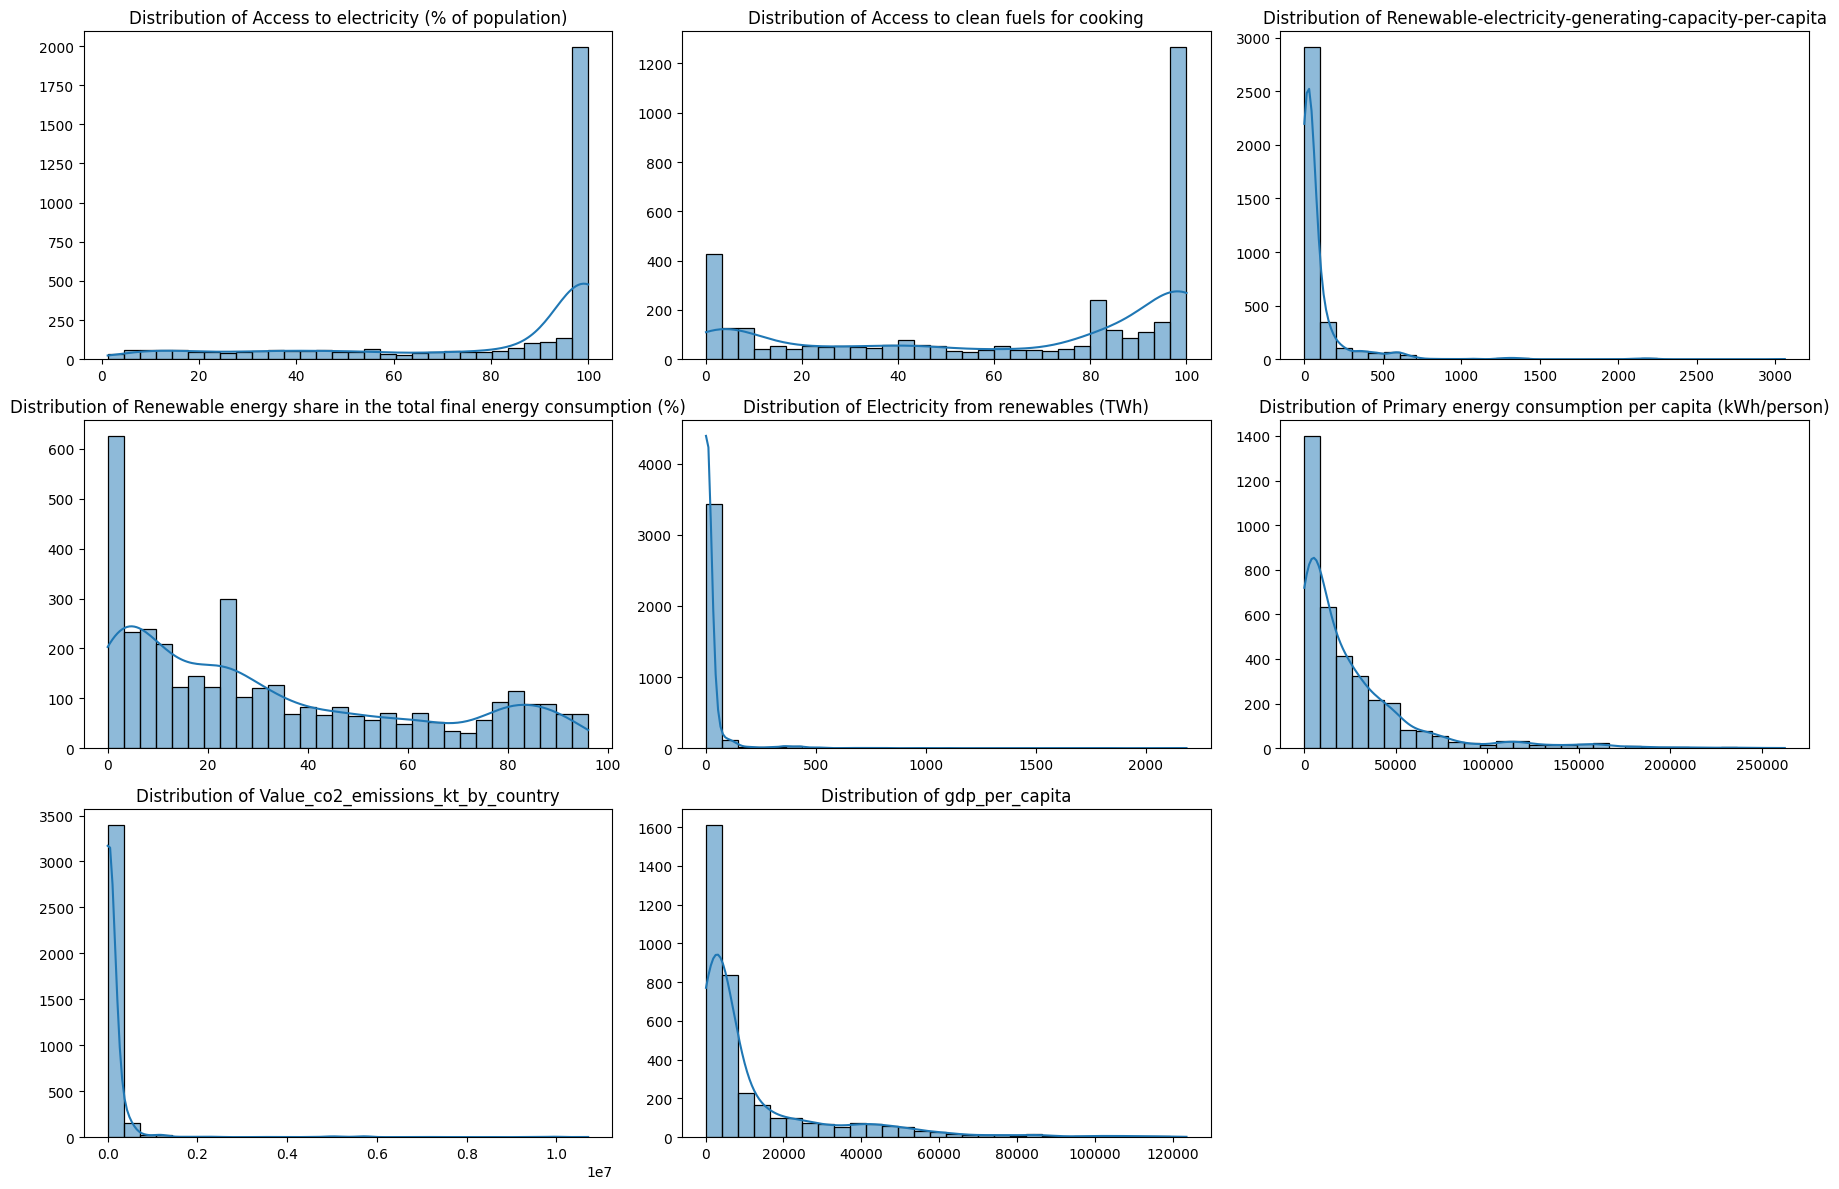

In [17]:
# Generalizations about 'Entity' and 'Year'
print(f"Number of unique entities (countries): {df.Entity.nunique()}")
print(f"Years covered: {df.Year.min()} to {df.Year.max()}")

# Visualize distributions of key numerical features
plt.figure(figsize=(18, 12))

# List of key features to visualize
key_features = [
    'Access to electricity (% of population)',
    'Access to clean fuels for cooking',
    'Renewable-electricity-generating-capacity-per-capita',
    'Renewable energy share in the total final energy consumption (%)',
    'Electricity from renewables (TWh)',
    'Primary energy consumption per capita (kWh/person)',
    'Value_co2_emissions_kt_by_country',
    'gdp_per_capita'
]

for i, feature in enumerate(key_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()


### Relationships Between Features: Correlation Analysis

To understand how different numerical features relate to each other, we'll compute and visualize their pairwise correlations using a heatmap. This can reveal strong positive or negative relationships, which are crucial for further analysis or modeling.

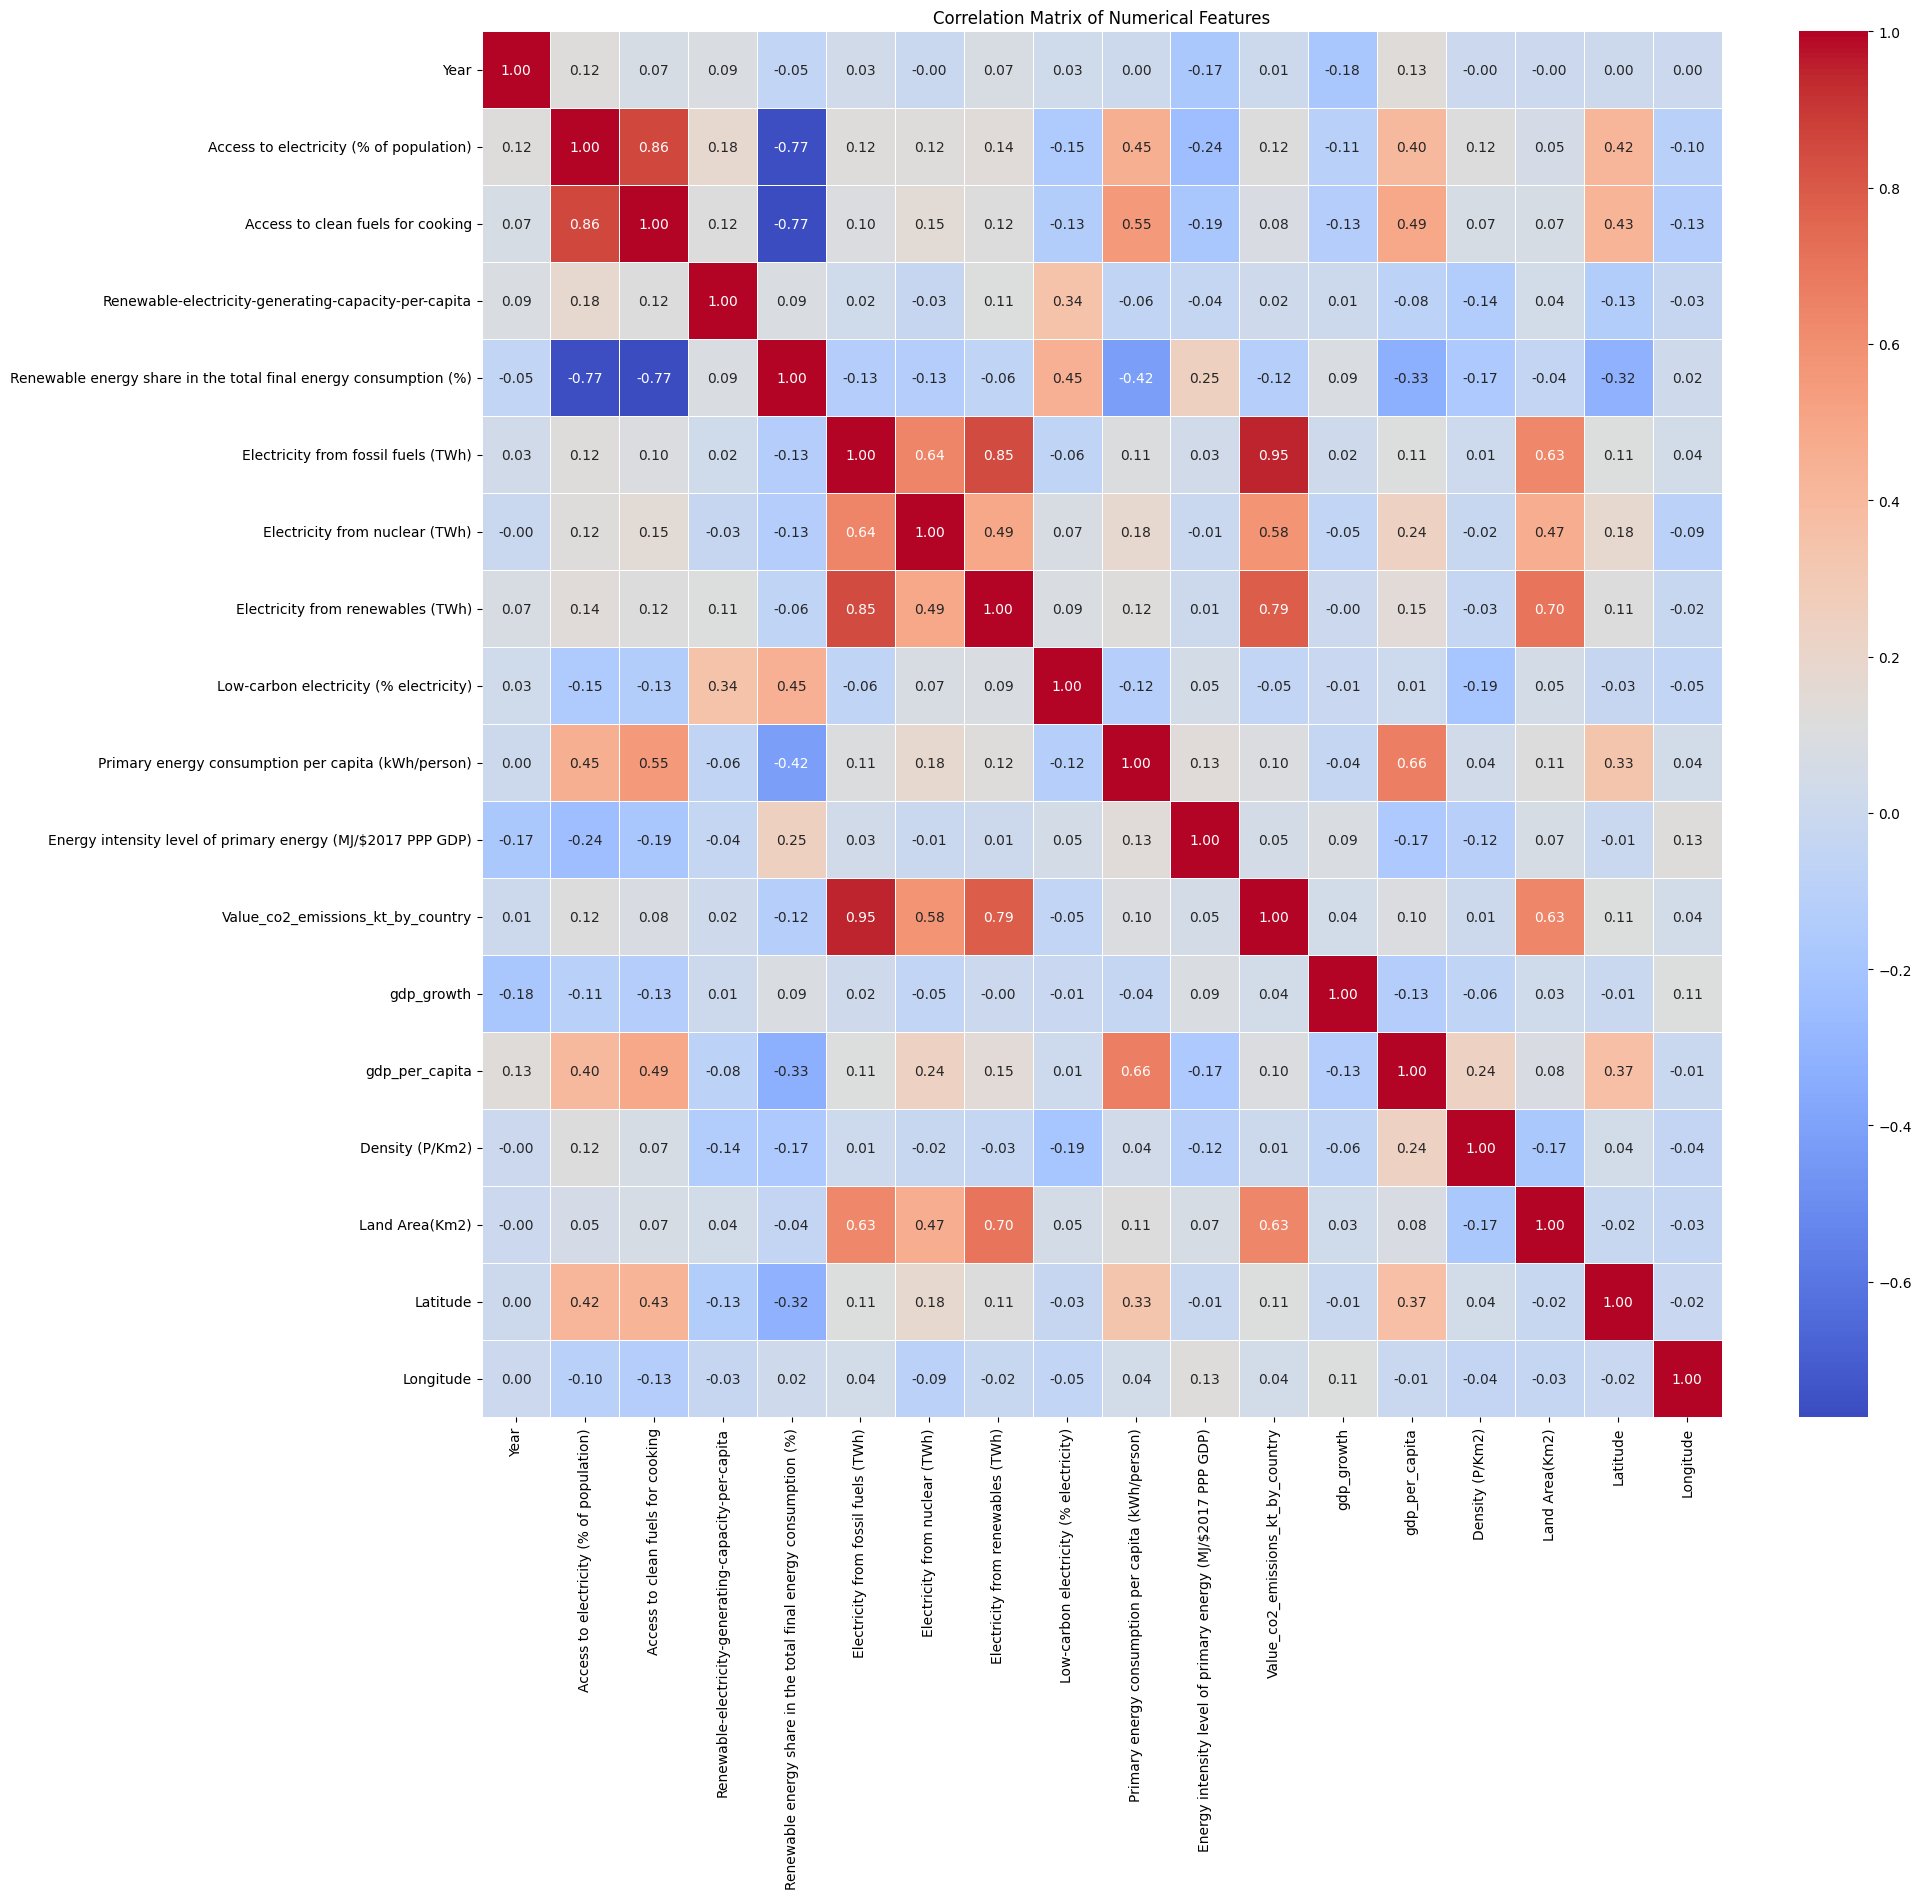

In [18]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Plot the correlation heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


## Feature Engineering

I will now create new features that could be insightful for understanding sustainable energy trends. Specifically, I'll calculate:

1.  **Green_Energy_Consumption_Ratio**: The ratio of 'Electricity from renewables (TWh)' to the total electricity generated (sum of 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', and 'Electricity from renewables (TWh)'). This feature will give us an idea of a country's reliance on renewable sources for electricity generation.
2.  **GDP_Per_Capita_Growth**: Derived from 'gdp_growth' to reflect the percentage change in GDP per capita, which is often a better indicator of individual economic prosperity and its potential links to energy consumption patterns.

In [19]:
# Calculate total electricity generation
df['Total_Electricity_Generation_TWh'] = df['Electricity from fossil fuels (TWh)'] + \
                                         df['Electricity from nuclear (TWh)'] + \
                                         df['Electricity from renewables (TWh)']

# Create Green_Energy_Consumption_Ratio
df['Green_Energy_Consumption_Ratio'] = df['Electricity from renewables (TWh)'] / df['Total_Electricity_Generation_TWh']

# Handle potential NaN or inf values if Total_Electricity_Generation_TWh was zero
df['Green_Energy_Consumption_Ratio'].fillna(0, inplace=True)
df['Green_Energy_Consumption_Ratio'].replace([np.inf, -np.inf], 0, inplace=True)

# Rename gdp_growth for clarity in relation to gdp_per_capita
df['GDP_Per_Capita_Growth'] = df['gdp_growth'] # Assuming gdp_growth already reflects per capita growth or is used as a proxy

# Display the first few rows with new features
display(df[['Entity', 'Year', 'Electricity from renewables (TWh)', 'Total_Electricity_Generation_TWh', 'Green_Energy_Consumption_Ratio', 'GDP_Per_Capita_Growth']].head())


/tmp/ipykernel_607/1891353193.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Green_Energy_Consumption_Ratio'].fillna(0, inplace=True)
/tmp/ipykernel_607/1891353193.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,Entity,Year,Electricity from renewables (TWh),Total_Electricity_Generation_TWh,Green_Energy_Consumption_Ratio,GDP_Per_Capita_Growth
0,Afghanistan,2000,0.31,0.47,0.659574,3.559855
1,Afghanistan,2001,0.50,0.59,0.847458,3.559855
2,Afghanistan,2002,0.56,0.69,0.811594,3.559855
3,Afghanistan,2003,0.63,0.94,0.670213,8.832278
4,Afghanistan,2004,0.56,0.89,0.629213,1.414118


## Scaling Numerical Columns and Encoding Categorical Columns

To prepare the data for potential machine learning models, it's crucial to scale numerical features and encode categorical ones. This ensures that all features contribute equally and that models can process non-numeric data.

### Scaling Numerical Features
I'll use `StandardScaler` to transform numerical columns so they have a mean of 0 and a standard deviation of 1. This prevents features with larger scales from dominating the learning process.

### Encoding Categorical Features
The 'Entity' column (representing countries) is a categorical feature. I'll use `LabelEncoder` to convert it into numerical labels. This is suitable for nominal categorical variables when the model does not assume ordinality.

In [20]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Remove 'Year' from numerical columns if it's not meant to be scaled as a continuous feature
# For time-series analysis, 'Year' might be handled differently, but for general ML, it can be treated numerically or as an identifier.
# For now, let's keep 'Year' as a numerical feature, as it indicates a trend.

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical columns (excluding 'Year' for now if specific year-based analysis is intended, but for general scaling, it can be included)
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("Scaled Numerical Features (first 5 rows of numerical columns):")
display(df_scaled[numerical_cols].head())

# Apply Label Encoding to 'Entity' column
encoder = LabelEncoder()
df_encoded = df_scaled.copy()
df_encoded['Entity_Encoded'] = encoder.fit_transform(df_encoded['Entity'])

# Drop the original 'Entity' column if it's no longer needed
df_encoded = df_encoded.drop(columns=['Entity'])

print("Encoded Categorical Features (first 5 rows of relevant columns):")
display(df_encoded[['Entity_Encoded', 'Year']].head())

# Display info of the final processed DataFrame
print("\nInfo of the final processed DataFrame:")
df_encoded.info()

Scaled Numerical Features (first 5 rows of numerical columns):


,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),...,Value_co2_emissions_kt_by_country,gdp_growth,gdp_per_capita,Density (P/Km2),Land Area(Km2),Latitude,Longitude,Total_Electricity_Generation_TWh,Green_Energy_Consumption_Ratio,GDP_Per_Capita_Growth
0,-1.658303,-2.558056,-1.511702,-0.390724,0.440606,-0.201180,-0.180943,-0.225954,0.857399,-0.731738,...,-0.194394,0.019872,-0.421154,-0.475101,0.012086,0.649744,0.797318,-0.218425,1.010837,0.019872
1,-1.493106,-2.476693,-1.485628,-0.392410,0.461525,-0.201382,-0.180943,-0.224129,1.407966,-0.733627,...,-0.194436,0.019872,-0.421154,-0.475101,0.012086,0.649744,0.797318,-0.218178,1.576899,0.019872
2,-1.327910,-2.300326,-1.459554,-0.394236,0.195069,-0.201266,-0.180943,-0.223553,1.302873,-0.734376,...,-0.194024,0.019872,-0.651813,-0.475101,0.012086,0.649744,0.797318,-0.217973,1.468848,0.019872
3,-1.162713,-2.124131,-1.425657,-0.396015,0.154946,-0.200748,-0.180943,-0.222881,0.888574,-0.733826,...,-0.193763,0.990248,-0.651223,-0.475101,0.012086,0.649744,0.797318,-0.217459,1.042889,0.990248
4,-0.997517,-1.948032,-1.389153,-0.397607,0.414886,-0.200690,-0.180943,-0.223553,0.768431,-0.734567,...,-0.194024,-0.375045,-0.650138,-0.475101,0.012086,0.649744,0.797318,-0.217562,0.919365,-0.375045


Encoded Categorical Features (first 5 rows of relevant columns):


,Entity_Encoded,Year
0,0,-1.658303
1,0,-1.493106
2,0,-1.327910
3,0,-1.162713
4,0,-0.997517



Info of the final processed DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 22 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Year                                                              3649 non-null   float64
 1   Access to electricity (% of population)                           3649 non-null   float64
 2   Access to clean fuels for cooking                                 3649 non-null   float64
 3   Renewable-electricity-generating-capacity-per-capita              3649 non-null   float64
 4   Renewable energy share in the total final energy consumption (%)  3649 non-null   float64
 5   Electricity from fossil fuels (TWh)                               3649 non-null   float64
 6   Electricity from nuclear (TWh)                                    3649 non-null   float6

## Insights and Justification

Throughout this analysis, several key steps were taken, each with a specific rationale:

1.  **Initial Data Exploration**: We started by using `df.head()`, `df.info()`, and `df.describe()` to quickly grasp the dataset's structure, identify data types, check for initial missing values, and understand the basic statistics of numerical columns. This is crucial for forming an initial understanding of the data's quality and characteristics.

2.  **Column Renaming and Type Conversion**: The column `Density\n(P/Km2)` had a newline character and was of 'object' type. This was addressed by programmatically renaming it to `Density (P/Km2)` for readability and converting it to a numeric type using `pd.to_numeric(errors='coerce')`. This ensured that the column could be used in numerical calculations and visualizations, while `errors='coerce'` robustly handled any non-numeric entries by turning them into `NaN`.

3.  **Handling Missing Values**:
    *   Columns with a very high percentage of missing values (e.g., 'Financial flows to developing countries (US $)' and 'Renewables (% equivalent primary energy)') were dropped. This is because imputing such a large proportion of missing data could introduce significant bias and distort the true underlying patterns.
    *   For other numerical columns with fewer missing values, **median imputation** was used. The median is preferred over the mean in the presence of skewed distributions or outliers, as it is less sensitive to extreme values, thus providing a more robust central tendency measure for imputation.

4.  **Generalizations and Visualizations (Histograms and Correlation Heatmap)**:
    *   **Histograms** were used to visualize the distribution of key numerical features. This helped in understanding the spread, central tendency, and skewness of variables like 'Access to electricity', 'Renewable energy share', and 'gdp_per_capita'. These plots can reveal outliers or multimodal distributions.
    *   A **correlation heatmap** was generated to visualize the pairwise relationships between all numerical features. This is invaluable for identifying strong positive or negative correlations, which can suggest potential dependencies, multicollinearity, or areas for further investigation (e.g., strong positive correlation between 'Access to electricity' and 'gdp_per_capita').

5.  **Feature Engineering**:
    *   **Green_Energy_Consumption_Ratio** was created to provide a normalized measure of renewable energy's contribution to total electricity. This composite feature can be more informative than individual absolute values and directly represents a key aspect of sustainability.
    *   **GDP_Per_Capita_Growth** was directly taken from `gdp_growth` assuming it's a proxy for per capita economic changes, aiming to capture economic dynamism relevant to energy policies and consumption.

6.  **Feature Scaling (StandardScaler)**: Numerical features were scaled using `StandardScaler`. This is a critical preprocessing step for many machine learning algorithms (e.g., gradient descent-based models, SVMs, k-Nearest Neighbors) that are sensitive to the scale of input features. Scaling ensures that no single feature dominates due to its larger magnitude, allowing algorithms to converge faster and perform better.

7.  **Categorical Encoding (LabelEncoder)**: The 'Entity' column, representing countries, was transformed using `LabelEncoder`. This converts categorical text data into numerical format, making it palatable for machine learning algorithms. While `OneHotEncoder` is often preferred for nominal data to avoid implying ordinality, `LabelEncoder` is a simpler choice when the number of categories is very high or for tree-based models that are less sensitive to such implications.

These steps collectively transform the raw dataset into a clean, well-structured, and appropriately formatted DataFrame, ready for advanced analysis or machine learning model development related to sustainable energy and related factors.